In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

In [3]:
print("=== Knowledge Distillation Tutorial ===\n")

# Step 1: Define Teacher and Student Models
print("Step 1: Creating Teacher and Student Models")
print("-" * 50)

class TeacherModel(nn.Module):
    """Large teacher model with more parameters"""
    def __init__(self, input_size=10, hidden_size=128, num_classes=3):
        super(TeacherModel, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )
    
    def forward(self, x):
        return self.layers(x)

=== Knowledge Distillation Tutorial ===

Step 1: Creating Teacher and Student Models
--------------------------------------------------


In [4]:
class StudentModel(nn.Module):
    """Smaller student model with fewer parameters"""
    def __init__(self, input_size=10, hidden_size=32, num_classes=3):
        super(StudentModel, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, num_classes)
        )
    
    def forward(self, x):
        return self.layers(x)

In [5]:
# Initialize models
teacher = TeacherModel()
student = StudentModel()

In [6]:
# Count parameters
teacher_params = sum(p.numel() for p in teacher.parameters())
student_params = sum(p.numel() for p in student.parameters())

print(f"Teacher Model Parameters: {teacher_params:,}")
print(f"Student Model Parameters: {student_params:,}")
print(f"Compression Ratio: {teacher_params/student_params:.1f}x smaller\n")

Teacher Model Parameters: 26,371
Student Model Parameters: 451
Compression Ratio: 58.5x smaller



In [7]:
# Step 2: Create synthetic dataset
print("Step 2: Creating Synthetic Dataset")
print("-" * 50)

def create_synthetic_data(n_samples=1000, input_size=10, num_classes=3):
    """Create synthetic classification dataset"""
    X = torch.randn(n_samples, input_size)
    # Create some pattern in the data
    y = ((X[:, 0] + X[:, 1] + X[:, 2]) > 0).long()
    y = y % num_classes  # Ensure labels are in correct range
    return X, y

# Create train and test datasets
X_train, y_train = create_synthetic_data(800)
X_test, y_test = create_synthetic_data(200)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Input features: {X_train.shape[1]}")
print(f"Number of classes: {len(torch.unique(y_train))}\n")

Step 2: Creating Synthetic Dataset
--------------------------------------------------
Training samples: 800
Test samples: 200
Input features: 10
Number of classes: 2



In [8]:
# Step 3: Train Teacher Model
print("Step 3: Training Teacher Model")
print("-" * 50)

def train_model(model, train_loader, epochs=20, lr=0.001):
    """Standard training procedure"""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    losses = []
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        
        avg_loss = epoch_loss / len(train_loader)
        losses.append(avg_loss)
        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")
    
    return losses

def evaluate_model(model, test_loader):
    """Evaluate model accuracy"""
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            outputs = model(batch_x)
            _, predicted = torch.max(outputs.data, 1)
            total += batch_y.size(0)
            correct += (predicted == batch_y).sum().item()
    return 100 * correct / total

# Train teacher model
teacher_losses = train_model(teacher, train_loader, epochs=20)
teacher_accuracy = evaluate_model(teacher, test_loader)
print(f"\nTeacher Model - Test Accuracy: {teacher_accuracy:.2f}%\n")

Step 3: Training Teacher Model
--------------------------------------------------
Epoch 5/20, Loss: 0.1450
Epoch 10/20, Loss: 0.1024
Epoch 15/20, Loss: 0.0985
Epoch 20/20, Loss: 0.0714

Teacher Model - Test Accuracy: 97.50%



In [9]:
# Step 4: Knowledge Distillation Training
print("Step 4: Knowledge Distillation Training")
print("-" * 50)

def distillation_loss(student_logits, teacher_logits, true_labels, temperature=3.0, alpha=0.7):
    """
    Compute knowledge distillation loss
    
    Args:
        student_logits: Raw outputs from student model
        teacher_logits: Raw outputs from teacher model  
        true_labels: Ground truth labels
        temperature: Temperature for softening probability distributions
        alpha: Weight for distillation loss vs hard loss
    """
    # Soft targets from teacher (temperature scaling)
    teacher_probs = F.softmax(teacher_logits / temperature, dim=1)
    student_log_probs = F.log_softmax(student_logits / temperature, dim=1)
    
    # Distillation loss (KL divergence)
    distillation_loss = F.kl_div(student_log_probs, teacher_probs, reduction='batchmean')
    distillation_loss *= (temperature ** 2)  # Scale back
    
    # Hard loss (standard cross-entropy)
    hard_loss = F.cross_entropy(student_logits, true_labels)
    
    # Combined loss
    total_loss = alpha * distillation_loss + (1 - alpha) * hard_loss
    
    return total_loss, distillation_loss, hard_loss

def train_student_with_distillation(student, teacher, train_loader, epochs=20, lr=0.001, temperature=3.0, alpha=0.7):
    """Train student model using knowledge distillation"""
    optimizer = optim.Adam(student.parameters(), lr=lr)
    teacher.eval()  # Teacher in evaluation mode
    
    losses = {'total': [], 'distillation': [], 'hard': []}
    
    print(f"Training with Temperature={temperature}, Alpha={alpha}")
    print("Alpha controls the balance: higher alpha = more focus on teacher knowledge")
    
    for epoch in range(epochs):
        student.train()
        epoch_losses = {'total': 0, 'distillation': 0, 'hard': 0}
        
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            
            # Get predictions
            student_logits = student(batch_x)
            with torch.no_grad():
                teacher_logits = teacher(batch_x)
            
            # Compute distillation loss
            total_loss, dist_loss, hard_loss = distillation_loss(
                student_logits, teacher_logits, batch_y, temperature, alpha
            )
            
            total_loss.backward()
            optimizer.step()
            
            # Track losses
            epoch_losses['total'] += total_loss.item()
            epoch_losses['distillation'] += dist_loss.item()
            epoch_losses['hard'] += hard_loss.item()
        
        # Average losses
        for key in epoch_losses:
            epoch_losses[key] /= len(train_loader)
            losses[key].append(epoch_losses[key])
        
        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1}/{epochs}")
            print(f"  Total Loss: {epoch_losses['total']:.4f}")
            print(f"  Distillation Loss: {epoch_losses['distillation']:.4f}")
            print(f"  Hard Loss: {epoch_losses['hard']:.4f}")
    
    return losses

# Train student with knowledge distillation
print("Training student model with knowledge distillation...")
distillation_losses = train_student_with_distillation(student, teacher, train_loader, epochs=20)

Step 4: Knowledge Distillation Training
--------------------------------------------------
Training student model with knowledge distillation...
Training with Temperature=3.0, Alpha=0.7
Alpha controls the balance: higher alpha = more focus on teacher knowledge
Epoch 5/20
  Total Loss: 3.3853
  Distillation Loss: 4.6093
  Hard Loss: 0.5291
Epoch 10/20
  Total Loss: 1.4259
  Distillation Loss: 1.9508
  Hard Loss: 0.2012
Epoch 15/20
  Total Loss: 0.4821
  Distillation Loss: 0.6458
  Hard Loss: 0.1001
Epoch 20/20
  Total Loss: 0.1866
  Distillation Loss: 0.2376
  Hard Loss: 0.0677


In [10]:
# Step 5: Compare with baseline student
print("\nStep 5: Training Baseline Student (without distillation)")
print("-" * 50)

# Train a baseline student without distillation for comparison
baseline_student = StudentModel()
baseline_losses = train_model(baseline_student, train_loader, epochs=20)


Step 5: Training Baseline Student (without distillation)
--------------------------------------------------
Epoch 5/20, Loss: 0.5487
Epoch 10/20, Loss: 0.2540
Epoch 15/20, Loss: 0.1558
Epoch 20/20, Loss: 0.1128


In [11]:
# Step 6: Evaluate and Compare Results
print("\nStep 6: Final Results Comparison")
print("=" * 50)

# Evaluate all models
teacher_acc = evaluate_model(teacher, test_loader)
student_acc = evaluate_model(student, test_loader)
baseline_acc = evaluate_model(baseline_student, test_loader)

print(f"Teacher Model (Large):           {teacher_acc:.2f}%")
print(f"Student with Distillation:       {student_acc:.2f}%")
print(f"Student without Distillation:    {baseline_acc:.2f}%")
print(f"Improvement from Distillation:   {student_acc - baseline_acc:.2f}%")


Step 6: Final Results Comparison
Teacher Model (Large):           97.50%
Student with Distillation:       98.00%
Student without Distillation:    99.00%
Improvement from Distillation:   -1.00%


In [12]:
# Step 7: Demonstrate soft predictions
print(f"\nStep 7: Understanding Soft vs Hard Predictions")
print("-" * 50)

# Take a sample batch to show prediction differences
sample_x, sample_y = next(iter(test_loader))

# Get predictions from all models
teacher.eval()
student.eval()
baseline_student.eval()

with torch.no_grad():
    teacher_logits = teacher(sample_x[:5])  # First 5 samples
    student_logits = student(sample_x[:5])
    baseline_logits = baseline_student(sample_x[:5])
    
    # Convert to probabilities
    teacher_probs = F.softmax(teacher_logits, dim=1)
    student_probs = F.softmax(student_logits, dim=1)
    baseline_probs = F.softmax(baseline_logits, dim=1)

print("Sample predictions for first 5 test samples:")
print("(Class probabilities: [Class 0, Class 1, Class 2])")
print()

for i in range(5):
    true_class = sample_y[i].item()
    print(f"Sample {i+1} (True class: {true_class}):")
    print(f"  Teacher:     [{teacher_probs[i][0]:.3f}, {teacher_probs[i][1]:.3f}, {teacher_probs[i][2]:.3f}]")
    print(f"  Student+KD:  [{student_probs[i][0]:.3f}, {student_probs[i][1]:.3f}, {student_probs[i][2]:.3f}]")
    print(f"  Baseline:    [{baseline_probs[i][0]:.3f}, {baseline_probs[i][1]:.3f}, {baseline_probs[i][2]:.3f}]")
    print()


Step 7: Understanding Soft vs Hard Predictions
--------------------------------------------------
Sample predictions for first 5 test samples:
(Class probabilities: [Class 0, Class 1, Class 2])

Sample 1 (True class: 1):
  Teacher:     [0.000, 1.000, 0.000]
  Student+KD:  [0.005, 0.995, 0.000]
  Baseline:    [0.032, 0.965, 0.003]

Sample 2 (True class: 0):
  Teacher:     [1.000, 0.000, 0.000]
  Student+KD:  [1.000, 0.000, 0.000]
  Baseline:    [0.995, 0.002, 0.003]

Sample 3 (True class: 1):
  Teacher:     [0.000, 1.000, 0.000]
  Student+KD:  [0.001, 0.999, 0.000]
  Baseline:    [0.015, 0.982, 0.003]

Sample 4 (True class: 0):
  Teacher:     [0.996, 0.004, 0.000]
  Student+KD:  [0.954, 0.046, 0.000]
  Baseline:    [0.823, 0.169, 0.007]

Sample 5 (True class: 0):
  Teacher:     [1.000, 0.000, 0.000]
  Student+KD:  [0.988, 0.012, 0.000]
  Baseline:    [0.947, 0.045, 0.008]



Step 8: Training Progress Visualization
--------------------------------------------------


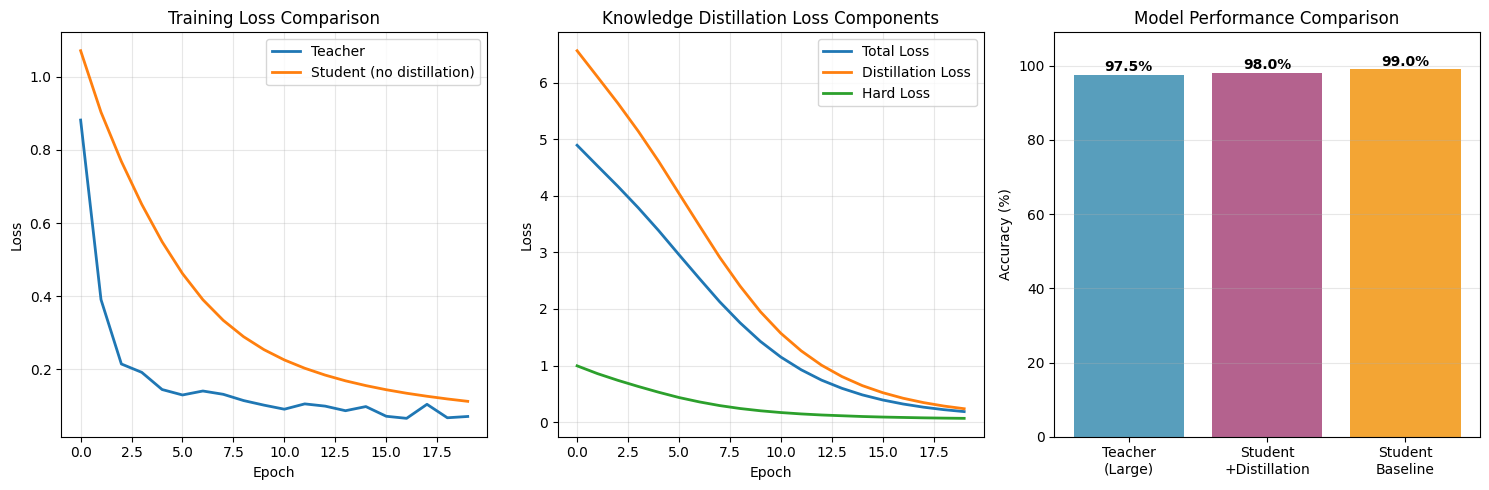


KNOWLEDGE DISTILLATION SUMMARY
✓ Teacher model trained with 26,371 parameters
✓ Student model has 451 parameters (58.5x smaller)
✓ Knowledge distillation improved student accuracy by -1.00%
✓ Student model achieved 100.5% of teacher performance with 98.3% fewer parameters

Key Concepts Demonstrated:
• Temperature scaling softens probability distributions
• Alpha parameter balances teacher knowledge vs ground truth
• Soft targets contain more information than hard labels
• Knowledge distillation enables model compression with minimal accuracy loss


In [13]:
# Step 8: Visualize training progress
print("Step 8: Training Progress Visualization")
print("-" * 50)

try:
    plt.figure(figsize=(15, 5))
    
    # Plot 1: Teacher vs baseline student training loss
    plt.subplot(1, 3, 1)
    plt.plot(teacher_losses, label='Teacher', linewidth=2)
    plt.plot(baseline_losses, label='Student (no distillation)', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss Comparison')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 2: Distillation loss components
    plt.subplot(1, 3, 2)
    plt.plot(distillation_losses['total'], label='Total Loss', linewidth=2)
    plt.plot(distillation_losses['distillation'], label='Distillation Loss', linewidth=2)
    plt.plot(distillation_losses['hard'], label='Hard Loss', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Knowledge Distillation Loss Components')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 3: Final accuracy comparison
    plt.subplot(1, 3, 3)
    models = ['Teacher\n(Large)', 'Student\n+Distillation', 'Student\nBaseline']
    accuracies = [teacher_acc, student_acc, baseline_acc]
    colors = ['#2E86AB', '#A23B72', '#F18F01']
    
    bars = plt.bar(models, accuracies, color=colors, alpha=0.8)
    plt.ylabel('Accuracy (%)')
    plt.title('Model Performance Comparison')
    plt.ylim(0, max(accuracies) + 10)
    
    # Add value labels on bars
    for bar, acc in zip(bars, accuracies):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                f'{acc:.1f}%', ha='center', fontweight='bold')
    
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()
    
except ImportError:
    print("Matplotlib not available for plotting, but all calculations completed successfully!")

print("\n" + "="*60)
print("KNOWLEDGE DISTILLATION SUMMARY")
print("="*60)
print(f"✓ Teacher model trained with {teacher_params:,} parameters")
print(f"✓ Student model has {student_params:,} parameters ({teacher_params/student_params:.1f}x smaller)")
print(f"✓ Knowledge distillation improved student accuracy by {student_acc - baseline_acc:.2f}%")
print(f"✓ Student model achieved {student_acc/teacher_acc*100:.1f}% of teacher performance with {100-student_params/teacher_params*100:.1f}% fewer parameters")

print(f"\nKey Concepts Demonstrated:")
print(f"• Temperature scaling softens probability distributions")
print(f"• Alpha parameter balances teacher knowledge vs ground truth")
print(f"• Soft targets contain more information than hard labels")
print(f"• Knowledge distillation enables model compression with minimal accuracy loss")